In [15]:
# ============================================================
# CELL 1: CLONE / UPDATE GITHUB REPOSITORY
# ============================================================

import os

REPO_URL = "https://github.com/AbrarYasir01/FashionMNIST-CNN-Assignment.git"
REPO_DIR = "/content/FashionMNIST-CNN-Assignment"

if os.path.exists(REPO_DIR):

    print("Repository already exists.")
    print("Updating repository...")

    %cd {REPO_DIR}
    !git pull

else:

    print("Cloning repository...")

    !git clone {REPO_URL} {REPO_DIR}

    %cd {REPO_DIR}

print("\nRepository ready!")
print("Current directory:", os.getcwd())

Repository already exists.
Updating repository...
/content/FashionMNIST-CNN-Assignment
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 13 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (13/13), 10.62 MiB | 10.44 MiB/s, done.
From https://github.com/AbrarYasir01/FashionMNIST-CNN-Assignment
   b409136..4db98c9  main       -> origin/main
Updating b409136..4db98c9
Fast-forward
 dataset/ankleboot.jpg | Bin 0 -> 734323 bytes
 dataset/bag.jpg       | Bin 0 -> 378378 bytes
 dataset/coat.jpg      | Bin 0 -> 536881 bytes
 dataset/dress.jpg     | Bin 0 -> 3218678 bytes
 dataset/pullover.jpg  | Bin 0 -> 564549 bytes
 dataset/sandal.jpg    | Bin 0 -> 305753 bytes
 dataset/shirt.jpg     | Bin 0 -> 790217 bytes
 dataset/sneaker.jpg   | Bin 0 -> 1012445 bytes
 dataset/trouser.jpg   | Bin 0 -> 1690044 bytes
 dataset/tshirt.jpg    | Bin 0 -> 1924137 bytes
 10 files changed, 

In [16]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
# ============================================================
# CELL 3: DEVICE AND REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [18]:
# ============================================================
# CELL 4: CLASS NAMES
# ============================================================

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

NUM_CLASSES = len(classes)

print("Number of classes:", NUM_CLASSES)

for i, name in enumerate(classes):
    print(i, ":", name)

Number of classes: 10
0 : T-shirt/top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle boot


In [19]:
# ============================================================
# CELL 5: CHECK CUSTOM DATASET
# ============================================================

custom_dir = "dataset"

if not os.path.exists(custom_dir):
    raise FileNotFoundError(
        "dataset folder was not found in the GitHub repository."
    )

custom_files = [
    f for f in os.listdir(custom_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Custom images found:", len(custom_files))

for filename in sorted(custom_files):
    print(" -", filename)

Custom images found: 10
 - ankleboot.jpg
 - bag.jpg
 - coat.jpg
 - dress.jpg
 - pullover.jpg
 - sandal.jpg
 - shirt.jpg
 - sneaker.jpg
 - trouser.jpg
 - tshirt.jpg


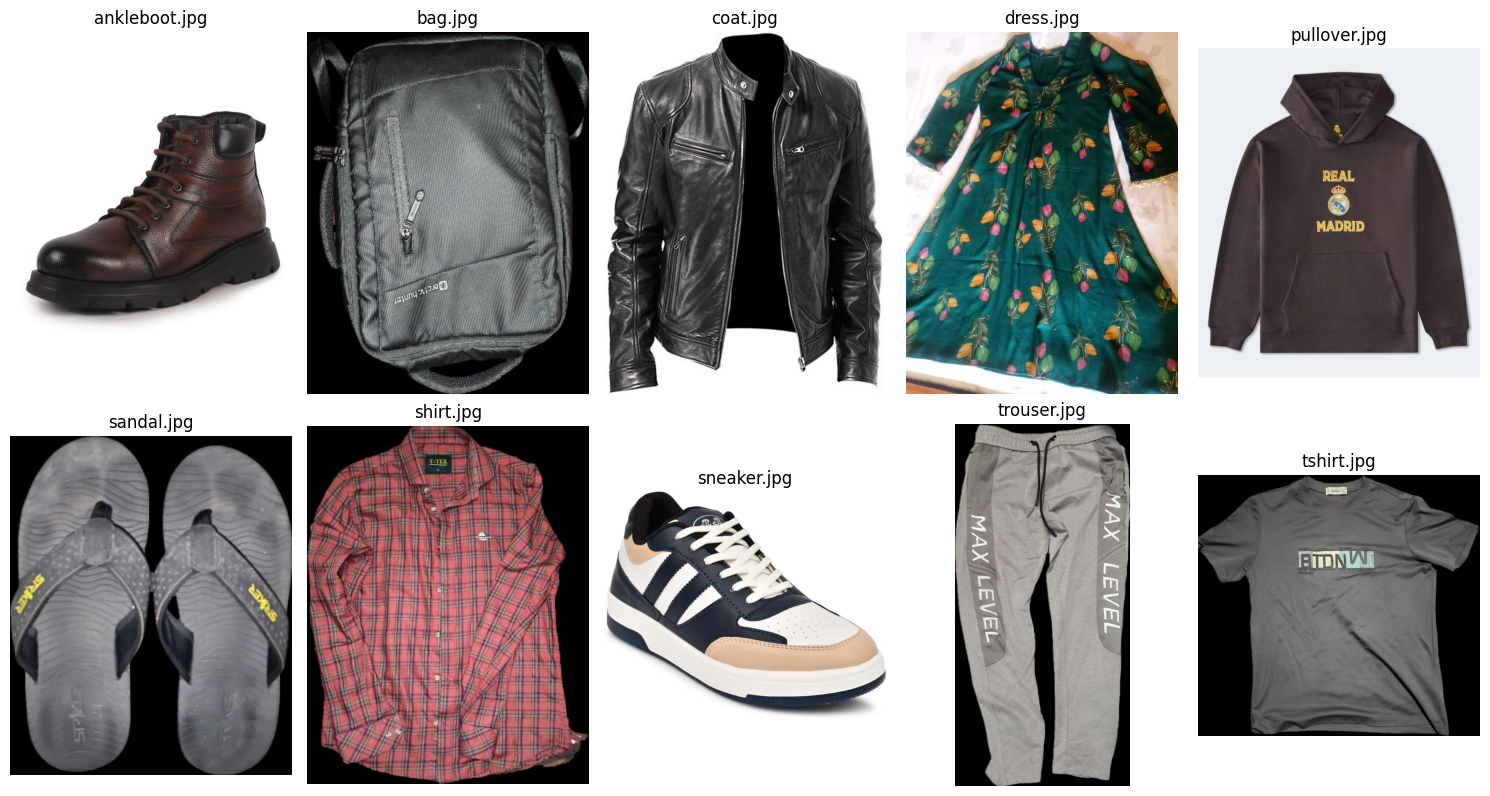

In [20]:
# ============================================================
# CELL 6: DISPLAY CUSTOM IMAGES
# ============================================================

plt.figure(figsize=(15, 8))

for i, filename in enumerate(sorted(custom_files)):

    image_path = os.path.join(custom_dir, filename)
    image = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CELL 7: IMAGE PREPROCESSING
# ============================================================

IMAGE_SIZE = 28

MEAN = (0.5,)
STD = (0.5,)

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

custom_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print("Transforms created successfully!")

Transforms created successfully!


In [22]:
# ============================================================
# CELL 8: DOWNLOAD FASHIONMNIST
# ============================================================

train_dataset_full = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("FashionMNIST downloaded successfully!")
print("Training samples:", len(train_dataset_full))
print("Testing samples:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]

FashionMNIST downloaded successfully!
Training samples: 60000
Testing samples: 10000


In [23]:
# ============================================================
# CELL 9: TRAIN / VALIDATION SPLIT
# ============================================================

train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 48000
Validation samples: 12000
Testing samples: 10000


In [24]:
# ============================================================
# CELL 10: DATALOADERS
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print("DataLoaders created!")

DataLoaders created!


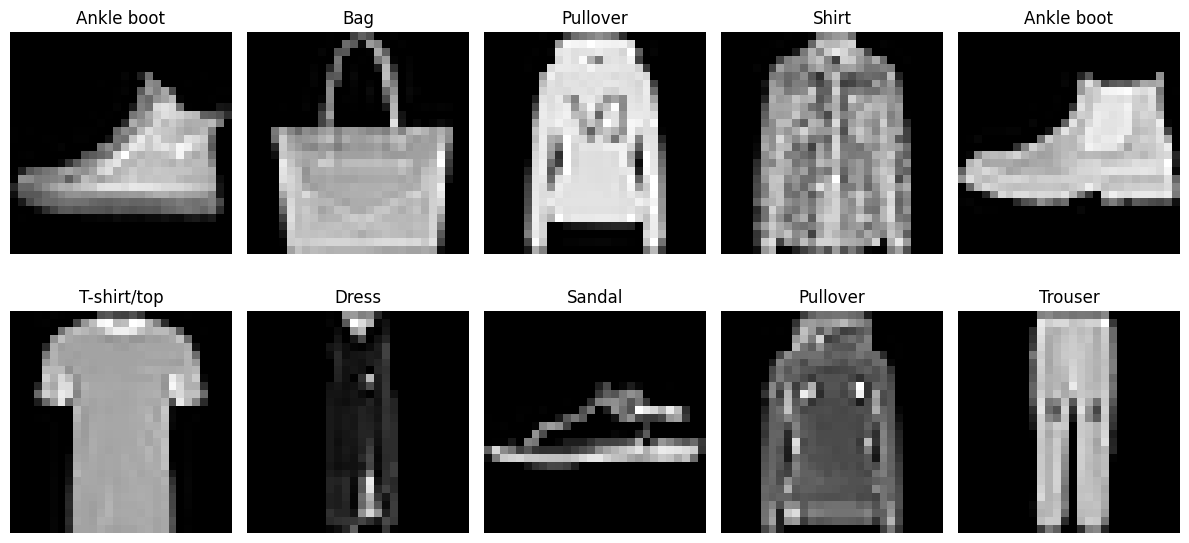

In [25]:
# ============================================================
# CELL 11: VIEW TRAINING IMAGES
# ============================================================

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))

for i in range(10):

    image = images[i].squeeze().numpy()

    # Undo normalization for visualization
    image = image * 0.5 + 0.5

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# CELL 12: CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            # First convolution block
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second convolution block
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),

            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [27]:
# ============================================================
# CELL 13: MODEL PARAMETERS
# ============================================================

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters: 421642
Trainable parameters: 421642


In [28]:
# ============================================================
# CELL 14: LOSS AND OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [29]:
# ============================================================
# CELL 15: TRAINING CONFIGURATION
# ============================================================

NUM_EPOCHS = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print("Epochs:", NUM_EPOCHS)

Epochs: 10


In [30]:
# ============================================================
# CELL 16: TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100.0 * correct / total


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            val_total += labels.size(0)
            val_correct += (
                predictions == labels
            ).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100.0 * val_correct / val_total


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [01/10] | Train Loss: 0.4675 | Train Acc: 83.16% | Val Loss: 0.3393 | Val Acc: 87.90%
Epoch [02/10] | Train Loss: 0.2927 | Train Acc: 89.42% | Val Loss: 0.2807 | Val Acc: 89.97%
Epoch [03/10] | Train Loss: 0.2439 | Train Acc: 91.15% | Val Loss: 0.2475 | Val Acc: 90.84%
Epoch [04/10] | Train Loss: 0.2100 | Train Acc: 92.30% | Val Loss: 0.2421 | Val Acc: 91.38%
Epoch [05/10] | Train Loss: 0.1859 | Train Acc: 93.24% | Val Loss: 0.2423 | Val Acc: 90.97%
Epoch [06/10] | Train Loss: 0.1606 | Train Acc: 94.10% | Val Loss: 0.2254 | Val Acc: 91.88%
Epoch [07/10] | Train Loss: 0.1415 | Train Acc: 94.80% | Val Loss: 0.2318 | Val Acc: 91.93%
Epoch [08/10] | Train Loss: 0.1206 | Train Acc: 95.56% | Val Loss: 0.2571 | Val Acc: 91.38%
Epoch [09/10] | Train Loss: 0.1023 | Train Acc: 96.22% | Val Loss: 0.2503 | Val Acc: 91.51%
Epoch [10/10] | Train Loss: 0.0874 | Train Acc: 96.85% | Val Loss: 0.2644 | Val Acc: 91.72%


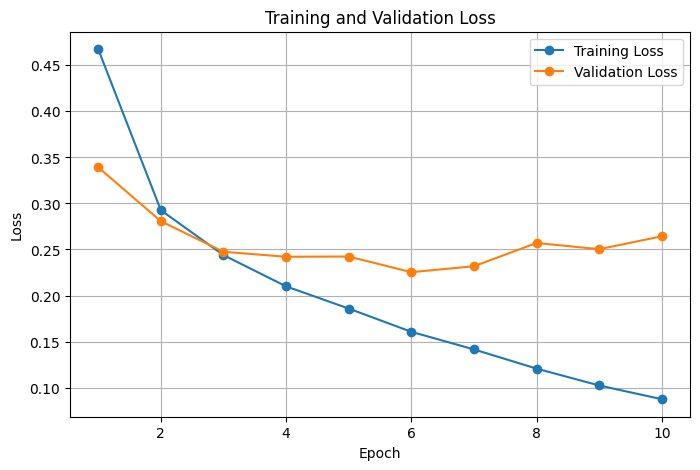

In [31]:
# ============================================================
# CELL 17: LOSS GRAPH
# ============================================================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

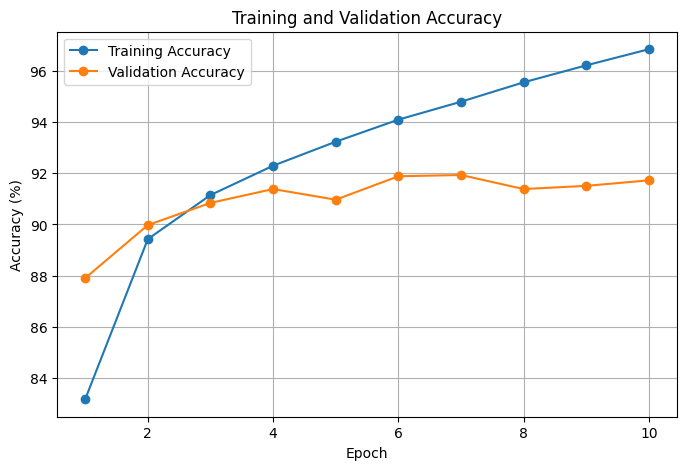

In [32]:
# ============================================================
# CELL 18: ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [33]:
# ============================================================
# CELL 19: FINAL VALIDATION RESULT
# ============================================================

print(
    f"Final Training Accuracy: "
    f"{train_accuracies[-1]:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{val_accuracies[-1]:.2f}%"
)

Final Training Accuracy: 96.85%
Final Validation Accuracy: 91.72%


In [34]:
# ============================================================
# CELL 20: TEST SET EVALUATION
# ============================================================

model.eval()

all_predictions = []
all_labels = []

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        test_total += labels.size(0)

        test_correct += (
            predictions == labels
        ).sum().item()

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = 100.0 * test_correct / test_total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 90.89%


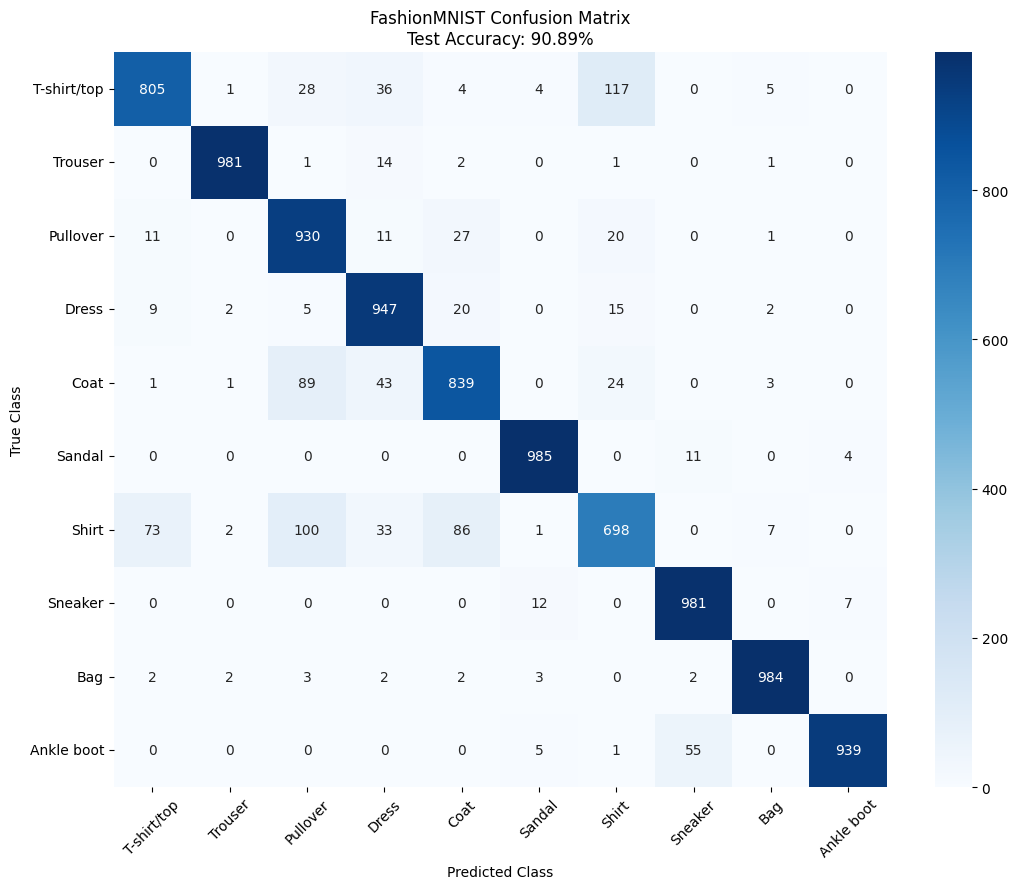

In [35]:
# ============================================================
# CELL 21: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    f"FashionMNIST Confusion Matrix\n"
    f"Test Accuracy: {test_accuracy:.2f}%"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# CELL 22: SAVE MODEL
# ============================================================

STUDENT_ID = "220140"

model_dir = "model"

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir,
    f"{STUDENT_ID}.pth"
)

torch.save(
    model.state_dict(),
    model_path
)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: model/220140.pth


In [38]:
# ============================================================
# CELL 23: FIND INCORRECT PREDICTIONS
# ============================================================

model.eval()

wrong_examples = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        for i in range(len(labels)):

            true_label = labels[i].item()
            predicted_label = predictions[i].item()

            if true_label != predicted_label:

                wrong_examples.append({
                    "image": images[i].cpu(),
                    "true": true_label,
                    "predicted": predicted_label
                })

            if len(wrong_examples) >= 3:
                break

        if len(wrong_examples) >= 3:
            break

print(
    "Incorrect examples found:",
    len(wrong_examples)
)

Incorrect examples found: 3


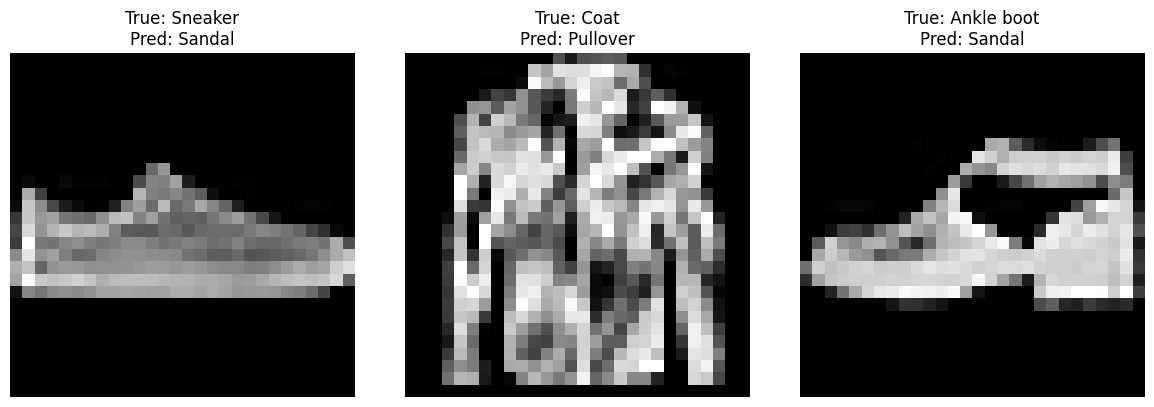

In [39]:
# ============================================================
# CELL 24: VISUAL ERROR ANALYSIS
# ============================================================

plt.figure(figsize=(12, 4))

for i, example in enumerate(wrong_examples):

    image = example["image"].squeeze().numpy()

    # Undo normalization
    image = image * 0.5 + 0.5

    plt.subplot(1, 3, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"True: {classes[example['true']]}\n"
        f"Pred: {classes[example['predicted']]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# CELL 25: LOAD SAVED MODEL
# ============================================================

saved_model_path = os.path.join(
    "model",
    f"{STUDENT_ID}.pth"
)

if os.path.exists(saved_model_path):

    loaded_model = CNN().to(device)

    loaded_model.load_state_dict(
        torch.load(
            saved_model_path,
            map_location=device
        )
    )

    loaded_model.eval()

    print(
        "Saved model loaded successfully!"
    )

else:

    print(
        "Saved model file is not currently "
        "present in the GitHub repository."
    )

Saved model loaded successfully!


In [41]:
# ============================================================
# CELL 26: CUSTOM IMAGE PREDICTION FUNCTION
# ============================================================

def predict_custom_image(image_path, model):

    image = Image.open(image_path).convert("RGB")

    image_tensor = custom_transform(image)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():

        output = model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, predicted_class = torch.max(
            probabilities,
            dim=1
        )

    predicted_index = predicted_class.item()

    confidence_percentage = (
        confidence.item() * 100
    )

    return (
        image,
        classes[predicted_index],
        confidence_percentage
    )

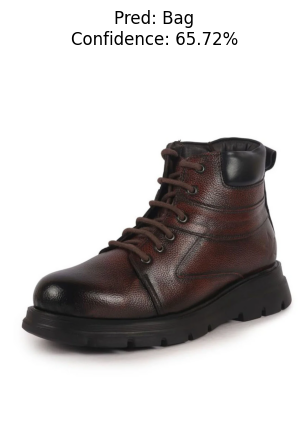

In [42]:
# ============================================================
# CELL 27: TEST ONE CUSTOM IMAGE
# ============================================================

first_image = sorted(custom_files)[0]

image_path = os.path.join(
    custom_dir,
    first_image
)

image, prediction, confidence = (
    predict_custom_image(
        image_path,
        model
    )
)

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    f"Pred: {prediction}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

In [43]:
# ============================================================
# CELL 28: PREDICT ALL CUSTOM IMAGES
# ============================================================

results = []

for filename in sorted(custom_files):

    image_path = os.path.join(
        custom_dir,
        filename
    )

    image, prediction, confidence = (
        predict_custom_image(
            image_path,
            model
        )
    )

    results.append({
        "filename": filename,
        "image": image,
        "prediction": prediction,
        "confidence": confidence
    })

print(
    f"Predicted {len(results)} custom images."
)

for result in results:

    print(
        f"{result['filename']:25s} "
        f"→ {result['prediction']:15s} "
        f"({result['confidence']:.2f}%)"
    )

Predicted 10 custom images.
ankleboot.jpg             → Bag             (65.72%)
bag.jpg                   → Bag             (65.33%)
coat.jpg                  → Bag             (99.98%)
dress.jpg                 → Bag             (100.00%)
pullover.jpg              → Bag             (100.00%)
sandal.jpg                → Trouser         (98.36%)
shirt.jpg                 → Bag             (63.71%)
sneaker.jpg               → Bag             (100.00%)
trouser.jpg               → Trouser         (97.03%)
tshirt.jpg                → T-shirt/top     (72.70%)


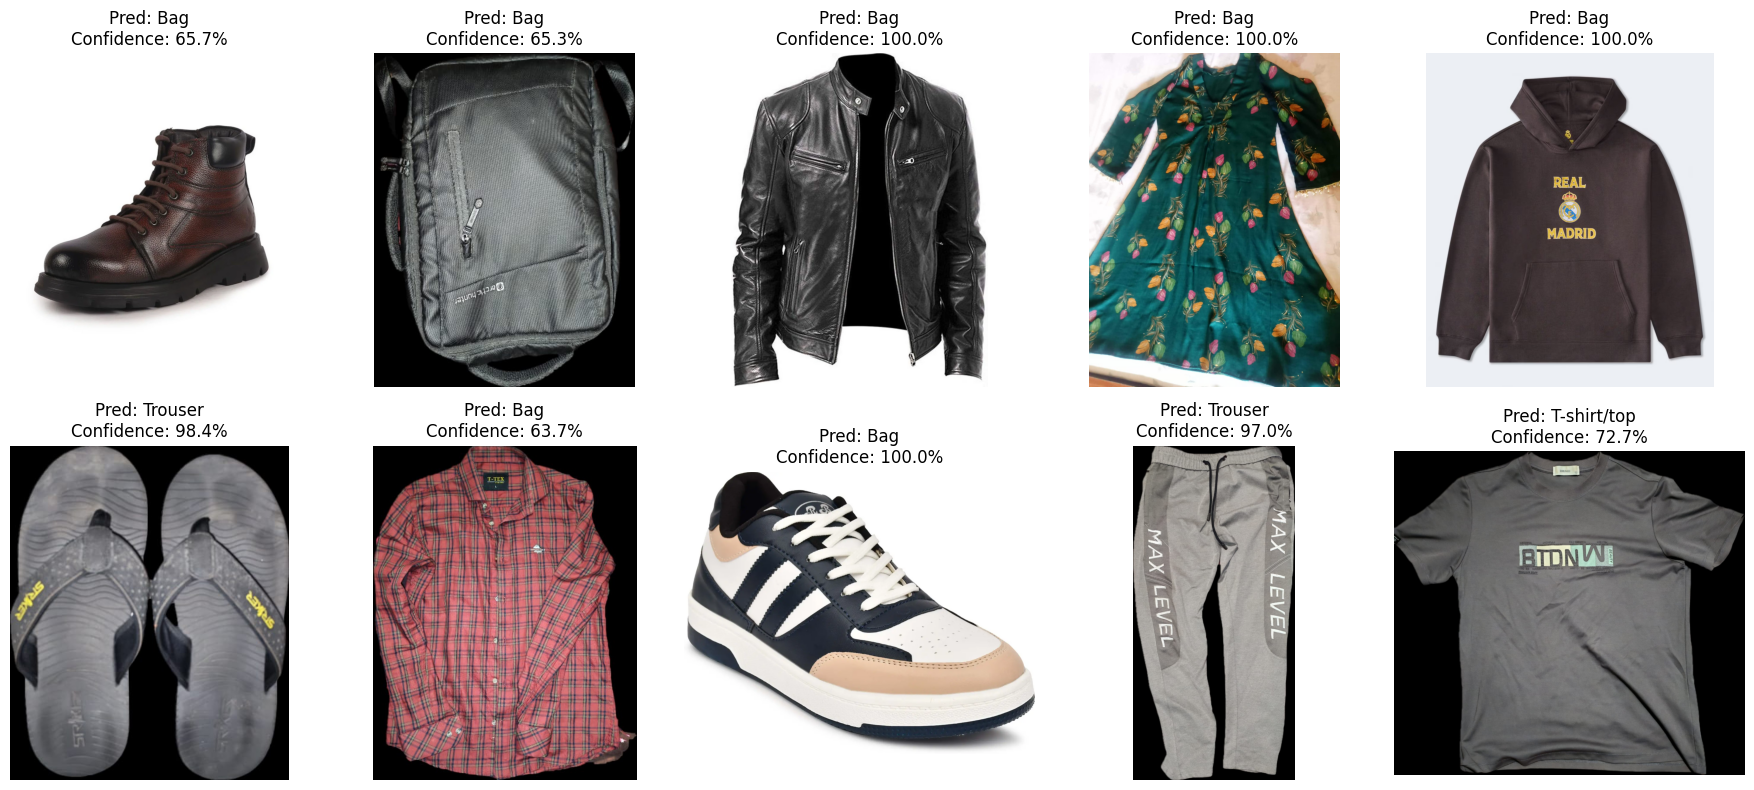

In [44]:
# ============================================================
# CELL 29: CUSTOM PREDICTION GALLERY
# ============================================================

num_images = len(results)

columns = 5
rows = int(np.ceil(num_images / columns))

plt.figure(
    figsize=(18, 4 * rows)
)

for i, result in enumerate(results):

    plt.subplot(
        rows,
        columns,
        i + 1
    )

    plt.imshow(result["image"])

    plt.title(
        f"Pred: {result['prediction']}\n"
        f"Confidence: {result['confidence']:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# CELL 30: CUSTOM RESULTS TABLE
# ============================================================

import pandas as pd

results_table = pd.DataFrame([
    {
        "Image": r["filename"],
        "Predicted Class": r["prediction"],
        "Confidence (%)": round(
            r["confidence"],
            2
        )
    }
    for r in results
])

results_table

,Image,Predicted Class,Confidence (%)
0,ankleboot.jpg,Bag,65.72
1,bag.jpg,Bag,65.33
2,coat.jpg,Bag,99.98
3,dress.jpg,Bag,100.00
4,pullover.jpg,Bag,100.00
5,sandal.jpg,Trouser,98.36
6,shirt.jpg,Bag,63.71
7,sneaker.jpg,Bag,100.00
8,trouser.jpg,Trouser,97.03
9,tshirt.jpg,T-shirt/top,72.70


In [46]:
# ============================================================
# CELL 31: FINAL SUMMARY
# ============================================================

print("=" * 60)
print("FASHIONMNIST CNN CLASSIFICATION - FINAL RESULTS")
print("=" * 60)

print(
    f"Training Accuracy   : "
    f"{train_accuracies[-1]:.2f}%"
)

print(
    f"Validation Accuracy : "
    f"{val_accuracies[-1]:.2f}%"
)

print(
    f"Test Accuracy       : "
    f"{test_accuracy:.2f}%"
)

print(
    f"Custom Images       : "
    f"{len(results)}"
)

print(
    f"Model File          : "
    f"{model_path}"
)

print("=" * 60)

FASHIONMNIST CNN CLASSIFICATION - FINAL RESULTS
Training Accuracy   : 96.85%
Validation Accuracy : 91.72%
Test Accuracy       : 90.89%
Custom Images       : 10
Model File          : model/220140.pth


In [47]:
import os

print(os.listdir("model"))

['220140.pth', 'YOUR_ID.pth']


In [48]:
import os

model_path = "model/" + STUDENT_ID + ".pth"

print("Model path:", model_path)
print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model size:", os.path.getsize(model_path), "bytes")

Model path: model/220140.pth
Exists: True
Model size: 1689919 bytes


In [49]:
from google.colab import files

files.download("model/220140.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>